# Trabajo Práctico Especial

Señales y Sistemas (TB065) - Curso 2 - Grupo 11 - 1C2025 - FIUBA  
Martin Klöckner - [mklockner@fi.uba.ar](mailto:mklockner@fi.uba.ar)  
Pablo Martinez Madero - [pmartinezm@fi.uba.ar](mailto:pmartinezm@fi.uba.ar)  
Ernesto Dei Castelli - [edei@fi.uba.ar](mailto:edei@fi.uba.ar)  

## Introducción

El habla humana puede ser entendida y analizada mediante modelos de sistemas lineales e invariantes en el tiempo (sistemas LTI). En este trabajo se considera la señal de voz como la salída de un sistema. La respuesta de este sistema varía en función de la fuente de la voz y la “configuración” del tracto vocal.

Cuando la señal de entrada tiene la forma de un tren de impulsos cuasi-períodicos, la salída tiene un patrón periódico lo que corresponde a sonidos vocálicos, como por ejemplo el sonido `[a]`. Cuando la señal de salída es no períodica, se pueden identificar sonidos fricativos, como por ejemplo `[s]`.

Se realiza un análisis de dos señales de muestra donde se identifican estas diferencias a partir de una visualización en el dominio del tiempo y posteriormente, en el dominio de la frecuencia.

## Obtención y Gráfico de Muestras

Para comenzar, como señal de muestra se realiza la grabación de dos muestras de voz, una rápida y una lenta pronunciando la palabra “Picasso”, de manera tal que la segunda tenga aproximadamente el doble de duracion que la primera, luego se procede a graficar las señales en el dominio del tiempo para lograr identificar regiones periódicas y no periódicas.

Para la realización de los gráficos se utiliza el lenguaje de programación
[python](https://www.python.org) junto con las librerías
[scipy](https://docs.scipy.org/doc/scipy/index.html),
[matplotlib](https://matplotlib.org/) y
[numpy](https://numpy.org/doc/stable/index.html).

Para empezar se importan las librerías mencionadas previamente en un script
de python, incluyendo el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) del módulo [urllib.request](https://docs.python.org/3/library/urllib.request.html#module-urllib.request) para obtener localmente los archivos a analizar.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.io import wavfile
from urllib.request import urlretrieve

Para obtener los archivos a analizar, se define una variable para almacenar el nombre de los archivos y se descargan utilizando el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) proporcionando las respectivas urls y el nombre final que se desea que tengan los archivos una vez descargados.

In [2]:
short_sample_file_name = 'picasso_short.wav'
long_sample_file_name = 'picasso_long.wav'

urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/tp/data/picasso_short.wav', short_sample_file_name);
urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/tp/data/picasso_long.wav', long_sample_file_name);

Continuamos leyendo el contenido del primer archivo de nombre `picasso_short.wav`, para lo cual se utiliza el método [wavfile.read](https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html#read) de la librería [scipy](https://docs.scipy.org/doc/scipy/index.html). Esta función devuelve los datos y la tasa de muestreo leidos del archivo en formato WAV cuyo nombre recibe como argumento.

In [3]:
short_sample_fs, short_sample_data = wavfile.read(short_sample_file_name)

Para graficar los datos obtenidos resulta conveniente definir la función `graph_data`, la cual utiliza métodos del módulo [pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot) de la librería [matplotlib](https://matplotlib.org/) para generar los gráficos pedidos. Esto además permite evitar patrones repetitivos en el código.

In [4]:
def graph_data(x, y, title, figure_number, t=0, dt=0, a=0, da=0,
               plot_type="default", tick=0, mesh_data=None, y_min=0, y_max=0):

  figure, axis = plt.subplots(num=title, figsize=(12, 6))
  figure_caption = 'Figura ' + str(figure_number) + ': ' + title
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)
  axis.grid(True)

  match plot_type:
    case "coef":
      markerline, stemline, baseline, = axis.stem(
          x, y, linefmt='-', markerfmt=' ', basefmt='-',
          label='Coeficientes de la Serie de Fourier')
      baseline.set_linewidth(0.25)
      baseline.set_color('black')
      markerline.set_marker('o')
      markerline.set_markersize(4)
      stemline.set_linewidth(1)
      axis.set(xlabel='Frecuencia [Hz]', ylabel='Amplitud')
    case "fft":
      axis.plot(x, y, label='Transformada de Fourier de la Señal')
      axis.set(xlabel='Frecuencia [Hz]', ylabel='Amplitud')
    case "spectogram":
      axis.pcolormesh(x, y, mesh_data, shading='gouraud', cmap="binary")
      axis.grid(False)
    case _: # default tiempo
      axis.plot(x, y, label='Señal de Audio')
      axis.set(xlabel='Tiempo [s]', ylabel='Amplitud')

  axis.set_xlim([t, t+dt if t != 0 else x[-1]])
  axis.set_ylim([y_min if y_min != 0 else axis.get_ylim()[0], y_max if y_max != 0 else axis.get_ylim()[1]])
  axis.axvspan(a, a+da, color='skyblue', alpha=0 if a == 0 else 0.50) # resaltado
  if tick != 0:
    from matplotlib.ticker import MultipleLocator
    figure.gca().xaxis.set_major_locator(MultipleLocator(tick))
  if plot_type != "spectogram":
    axis.legend()
  figure.show()
  return figure, axis

Para poder graficar los datos se necesita saber a qué tiempo corresponde cada valor de la señal; para eso, se utiliza el método [arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy-arange) de la libreria [numpy](https://numpy.org/doc/stable/index.html). Este método devuelve un arreglo de números equidistantes del largo que recibe como parámetro, en este caso del largo de los datos leídos del archivo. Para convertirlo a segundos se divide por la tasa de muestreo, la cual también se obtiene cuando se lee el archivo.

In [5]:
short_sample_time = np.arange(len(short_sample_data)) / short_sample_fs

Se define una variable para almacenar el título de la figura, esto para posteriormente pasarlo como argumento a la función `graph_data`.

In [6]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'

Finalmente se grafica el pimer archivo utilizando la funcion `graph_data`

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Tiempo [s]', ylabel='Amplitud'>)

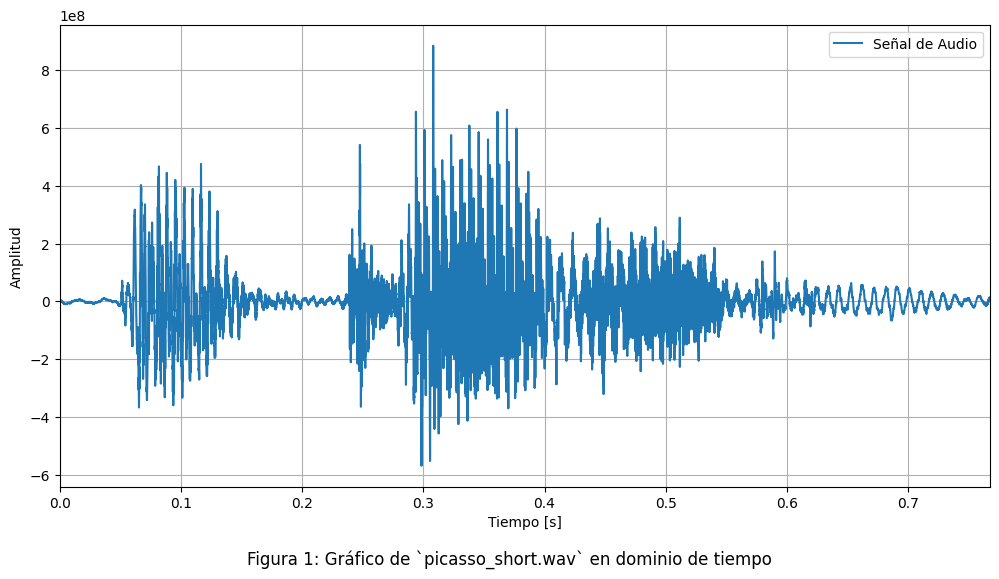

In [7]:
graph_data(short_sample_time, short_sample_data, title, 1)

Ahora realizamos exactamente el mismo procedimiento para el segundo archivo de aproximadamente el doble de duración.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Tiempo [s]', ylabel='Amplitud'>)

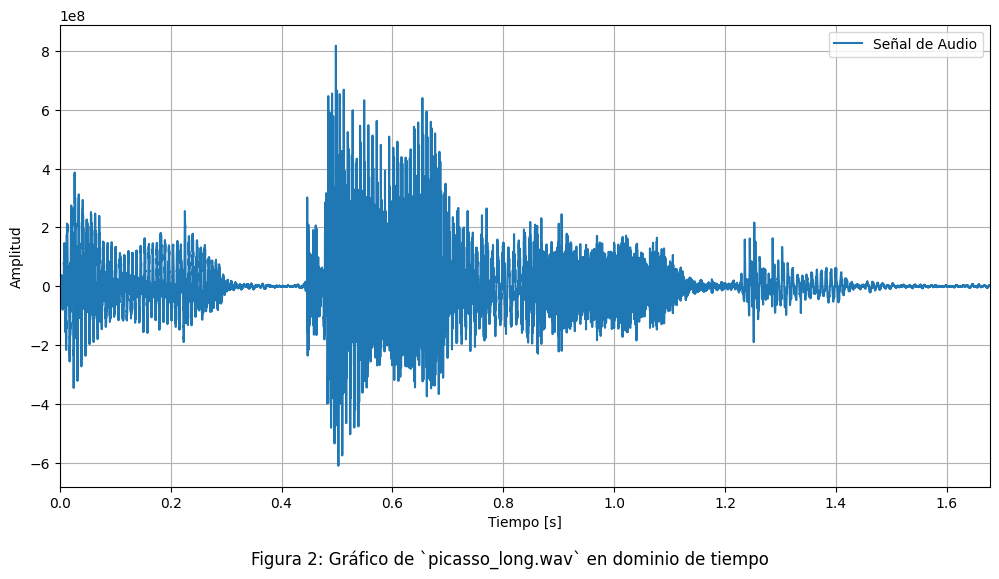

In [8]:
long_sample_fs, long_sample_data = wavfile.read(long_sample_file_name)
long_sample_time = np.arange(len(long_sample_data)) / long_sample_fs
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 2)

## Analisis Visual en Dominio de Tiempo

Haciendo una inspeccion visual de las señales graficadas en las figuras 1 y 2, se identifican ciertas partes que tienen un patrón que se repite después de un intervalo de tiempo.

Para el primer archivo, se toma como ejemplo el intervalo entre `0.08s` y `0.12s` en los cuales se observa un período que parece repetirse cada `0.0073s`, esto resulta en una frecuencia de aproximadamente `137Hz`. Dicho intervalo de la señal se puede ver en figura 3, en la cual también se resalta el período de la misma.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Tiempo [s]', ylabel='Amplitud'>)

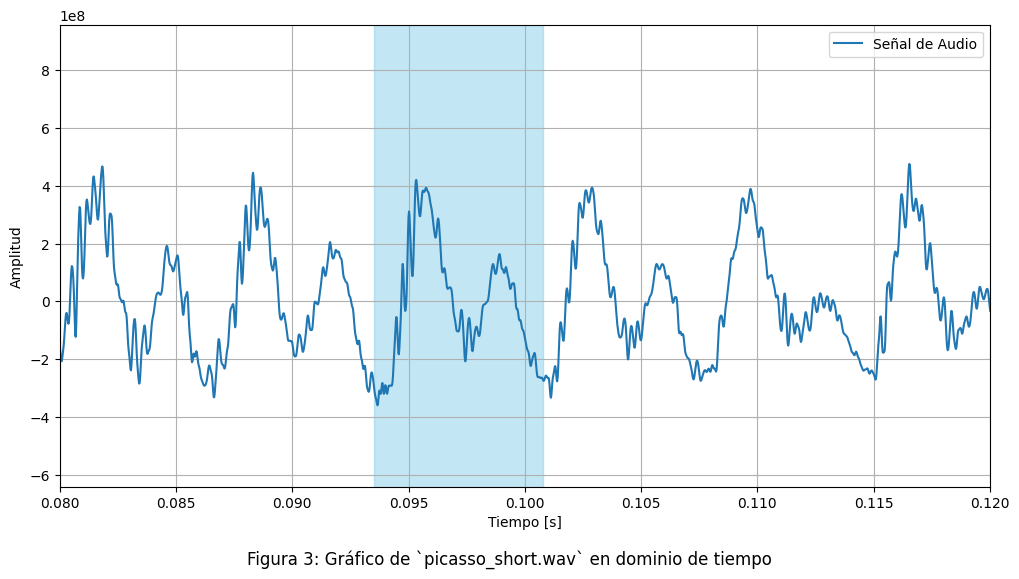

In [9]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 3, t=0.08, dt=0.04, a=0.0935, da=0.0073)

De manera analoga para el segundo archivo, de mayor duración, se realiza una inspección visual de la señal, en este caso se toma el intervalo entre `0.152s` y `0.206s` como se observa en la figura 4, además en la misma se grafica el periodo fundamental el cual resulta aproximadamente `0.0076s`, resultando en una frecuencia aproximada de `131.5Hz`

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Tiempo [s]', ylabel='Amplitud'>)

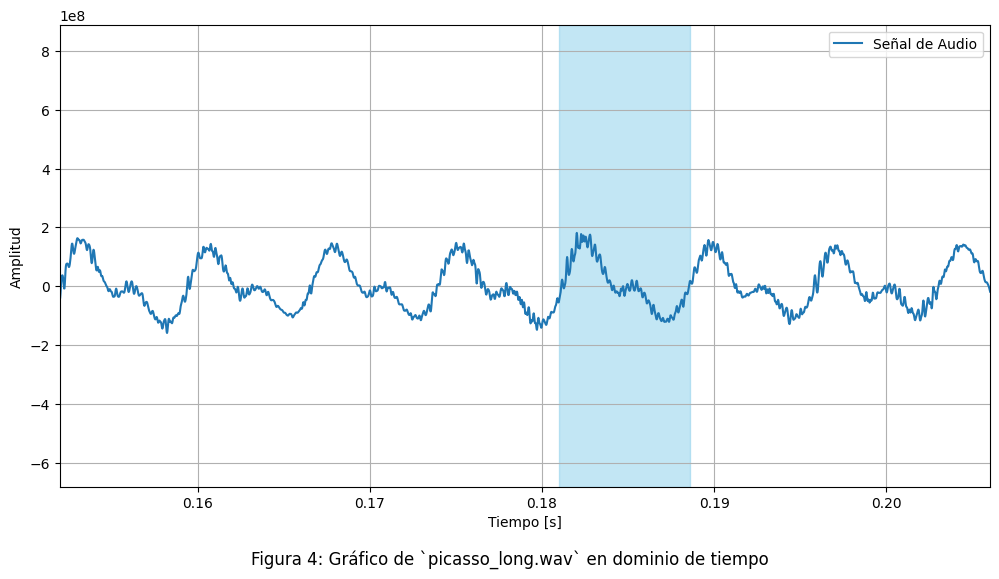

In [10]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 4, t=0.152, dt=0.054, a=0.181, da=0.0076)

Realizando un analisis similar que el realizado para buscar intervalos peridicos, se realiza una inspeccion visual de la señal, pero esta vez buscando patrones no repetitivos.

La figura 5 a continuación se muestra el intervalo `[0.246, 0.256]s` de la señal del archivo corto, en este intervalo la señal resulta no períodica, ya que se puede ver un patrón no repetitivo.

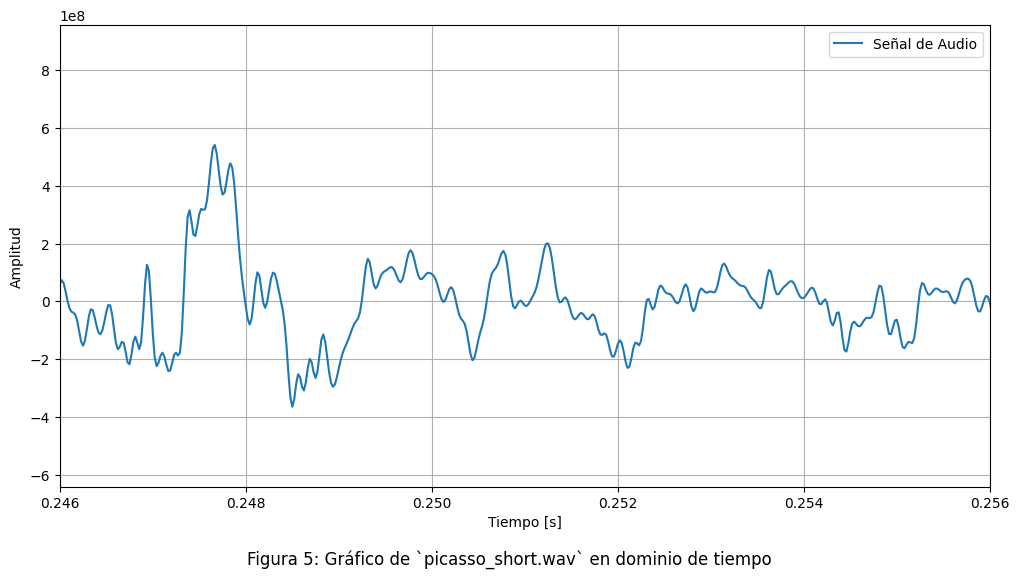

In [11]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 5, t=0.246, dt=0.01);

Para el archivo largo se toma el intervalo entre `0.445s` y `0.460s` como ejemplo de intervalo no periodico de la señal, este intervalo se puede ver en la figura 6 a continuación.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Tiempo [s]', ylabel='Amplitud'>)

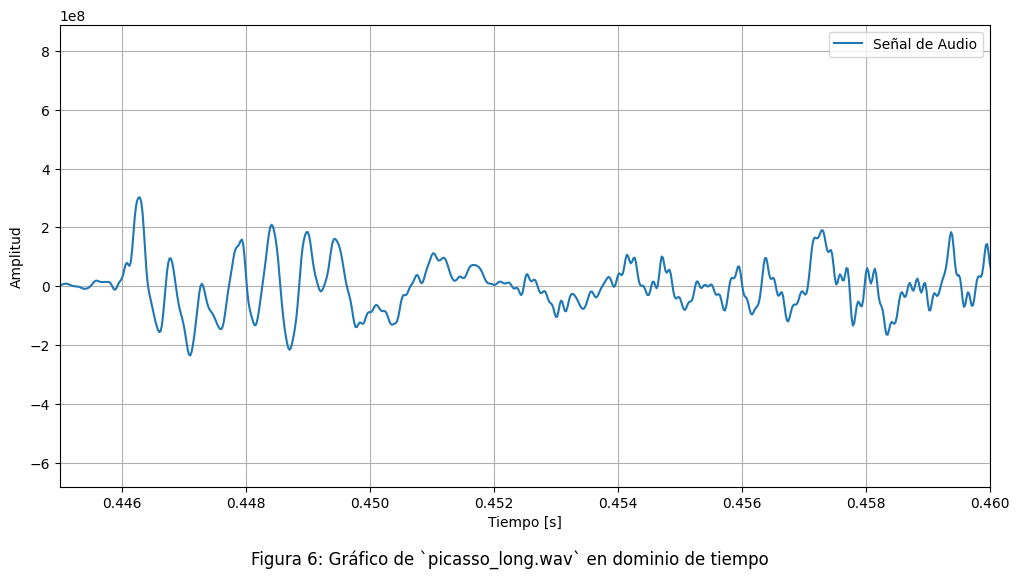

In [12]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 6, t=0.445, dt=0.015)

### Identificación de los sonidos vocalicos y fricativos

Los sonidos vocalicos corresponden con patrones repetivos, es decir periodicos, de la señal, como se mencionó en la introducción. Para identificar los sonidos vocalicos de la palabra "Picasso", pronunciada en los archivos de muestra, se buscan estos patrones repetitivos, como se realizo previamente por inspección visual.

En la figura 7 se muestra el intervalo `[0.35, 0.40]s` del archivo corto, en el intervalo se identifica el sonido vocalico `[a]` ya que es una señal periodica y escuchando el archivo de muestra se puede aproximar a ese tiempo dicha vocal, además en la figura se resalta un período, entre `[0.361, 0.369]s`, siendo el período de `0.008s` y por ende la frecuencia `125Hz`.

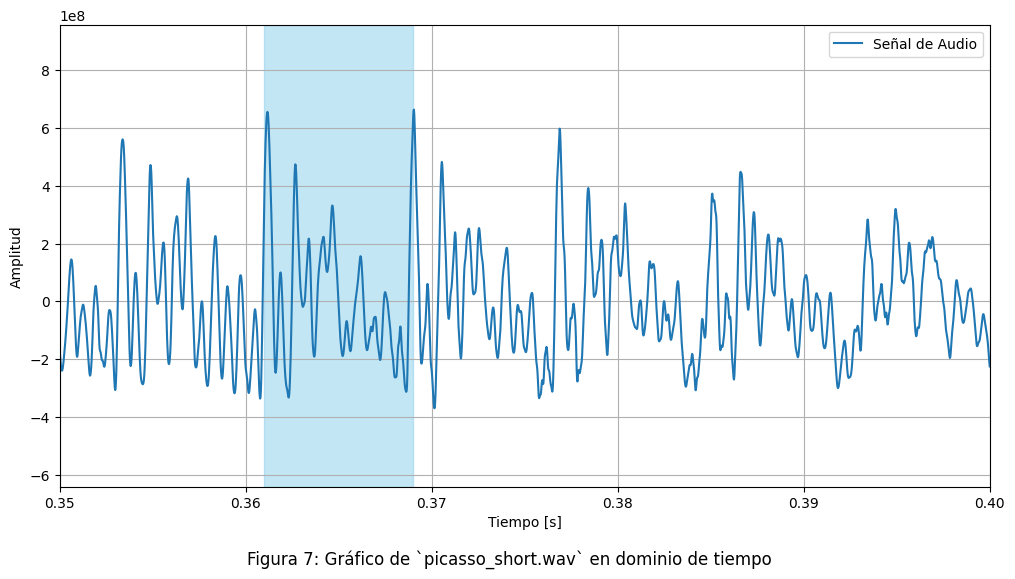

In [13]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 7, t=0.35, dt=0.05, a=0.361, da=0.008);

El sonido fricativo `[s]` corresponde con una señal de entrada del sistema de ruido blanco y con una salida no períodica, este patrón se identifica en la figura 8, en la cual se puede ver que parece haber un patrón repetitivo y asemejarse a una señal senoidal, no se puede considerar períodica porque la señal montada, o ruido, no es períodica, pero si se puede decir que es cuasi-períodica, y se puede aproximar el periodo a `0.01s` y por ende la frecuencia a `100Hz`.

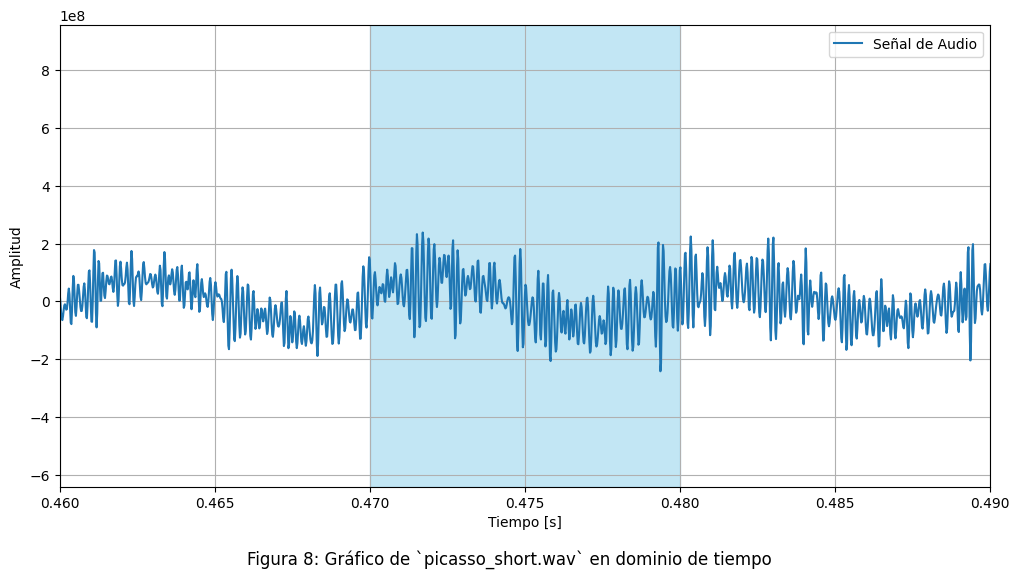

In [14]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 8, t=0.46, dt=0.03, a=0.47, da=0.01);

En la figura 9 se analiza el intervalo `[0.7, 0.8]s` de la señal de mayor duracion, donde se identifica el sonido vocálico `[a]`. Al igual que en la señal corta, se observa un patrón periódico en la forma de onda, característico de los sonidos vocálicos. En particular, se resalta un ciclo entre `[0.740, 0.748]s`, correspondiente a un período de `0.008s`, y por ende una frecuencia fundamental de `125Hz`.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Tiempo [s]', ylabel='Amplitud'>)

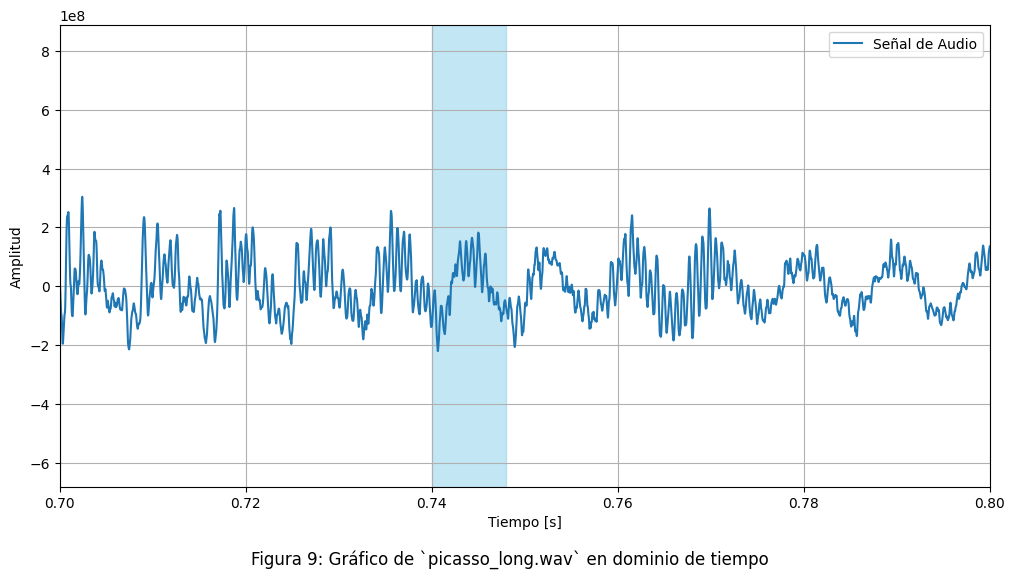

In [15]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 9, t=0.7, dt=0.1, a=0.74, da=0.008)

En la figura 10 a continuación, se analiza el intervalo `[0.765, 0.852]s` de la señal larga, donde se identifica el fonema fricativo `[s]`. Este tipo de sonido presenta una señal aperiodica, dominada por ruido.
Aunque se puede visualizar un patrón oscilatorio entre `[0.797, 0.798]s` como se muestra resaltado, este no corresponde a un período real sino a una oscilación irregular. Se aproxima un pseudo-período de `0.01s`, resultando en una frecuencia aparente de `100Hz`, aunque sin significado físico como frecuencia fundamental.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Tiempo [s]', ylabel='Amplitud'>)

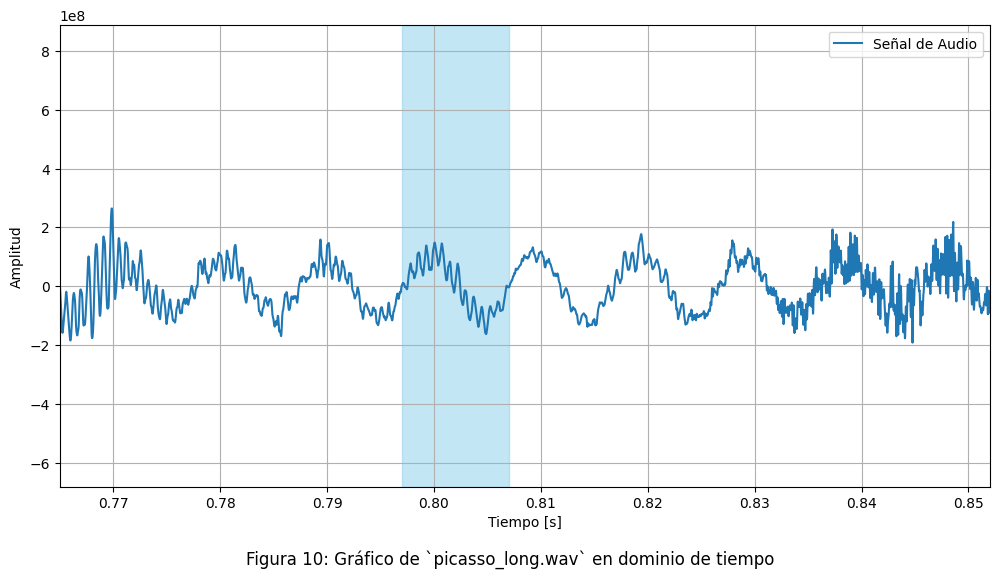

In [16]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 10, t=0.765, dt=0.087, a=0.797, da=0.01)


## Analisis en Frecuencia

Para calcular los coeficientes de Fourier, se utiliza los metodos [fft](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fft.html#scipy.fft.fft) y [fftfreq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fftfreq.html#fftfreq) del modulo [fft](https://docs.scipy.org/doc/scipy/reference/fft.html#discrete-fourier-transforms-scipy-fft) de la libreria [scipy](https://docs.scipy.org/doc/scipy/index.html). Se define la funcion `graph_fourier` la cual permite graficar tanto los coeficientes de la serie de Fourier del intervalo definido por `[x, y]` como la transformada de la misma, para el mismo intervalo. Tambien se utilizan algunas funciones más para graficar la envolvente del gráfico de los coeficientes de Fourier y tambien los primeros 3 formantes, que se obtienen a partir de los primeros 3 máximos de la envolvente.

In [17]:
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

def graph_fourier(data, fs, t, dt, title, fig_num, f_max, coef=False, ticks=0, formantes=True):
  interval_data = data[int(t*fs):int((t+dt)*fs)]
  interval_fft = fft(interval_data)
  interval_freqs = fftfreq(len(interval_data), d=1/fs)

  # Se toma la parte positiva en ambos casos (primer parte del arreglo)
  x = interval_freqs[:len(interval_data) // 2]
  y = np.abs(interval_fft[:len(interval_data) // 2])

  fig, ax = graph_data(x, y, title, fig_num, 0.01 if f_max != 0 else 0, f_max, plot_type="coef" if coef is True else "fft", tick=ticks)

  if formantes != False:
    # Se buscan los maximos y se hace una interpolacion cuadratica
    x_peaks, y_peaks = x[peaks := find_peaks(y)[0]], y[peaks]
    envelope = interp1d(x_peaks, y_peaks, kind='cubic', fill_value='extrapolate')(x)

    # Se obtienen los primeros 3 formantes de los primeros 3 maximos de la envolvente
    peaks, _ = find_peaks(envelope)
    peak_values = envelope[peaks]
    top_3_indices = np.argsort(peak_values)[-3:][::-1]  # Se ordena y se toman los primeros 3
    top_3_peaks = peak_values[top_3_indices]
    top_3_peak_positions = peaks[top_3_indices]

    # Se grafica la envolvente y los formantes encima del grafico de los coeficientes de fourier
    ax.plot(x, envelope, label='Envolvente', color='orange')
    for i, (value, pos) in enumerate(zip(top_3_peaks, top_3_peak_positions)):
        plt.plot(x[pos], value, 'bs', markeredgewidth=2, markeredgecolor='red', markerfacecolor='none', label=f"Formante {i+1} $\\approx$ {x[pos]:.0f} Hz")
        print(f"{x[pos]:.0f}")

    ax.legend()
    fig.canvas.draw()
    ax.set_ylim([ax.get_ylim()[0], (1.10)*np.max(envelope)])

### Archivo corto

La palabra "Picasso" pronunciada en el archivo de muestra cuenta con 3 vocales: "a", "i" y "o", ya identificamos el intervalo en donde se pronuncia la "a", el cual se muestra en la figura 7 y 9 para el archivo corto y largo respectivamente, a continuación se utiliza la funcion `graph_fourier` definida previamente para calcular los coeficientes de fourier, utilizando el intervalo `[0.361, 0.369]s` de la señal corta, en el cual se encuentra un solo periodo de la señal periodica producto de pronunciar la "a".

750
2500
3875


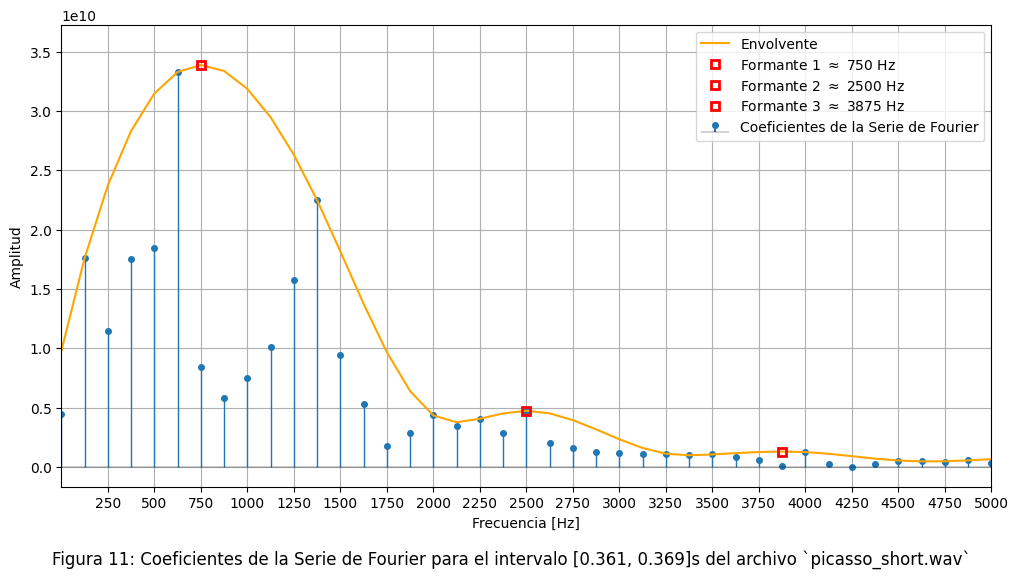

In [18]:
t=0.361
dt=0.008 # 0.361 + 0.008 = 0.369
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}]s del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 11, 5000, coef=True, ticks=250)

En la leyende se pueden ver los primeros 3 formantes en aproximadamente `750Hz`, `2500Hz` y `3875Hz` respectivamente.

Tomando 4 periodos de la señal, los coeficientes de Fourier resultan como se ve en la figura 12 a continuación, se puede ver que tiene mucho mas "detalle" que la figura 11, y tiene sentido ya que se tiene más información, también se puede ver que la envolvente, la cual proviene de realizar una interpolación, tiene picos más abruptos que cuando se tomaba solo 1 período, esto tambien es causa de tener más datos. En este caso los primeros 3 formantes resultan en `1404Hz`, `638Hz` y en `128Hz` respectivamente.


1404
638
128


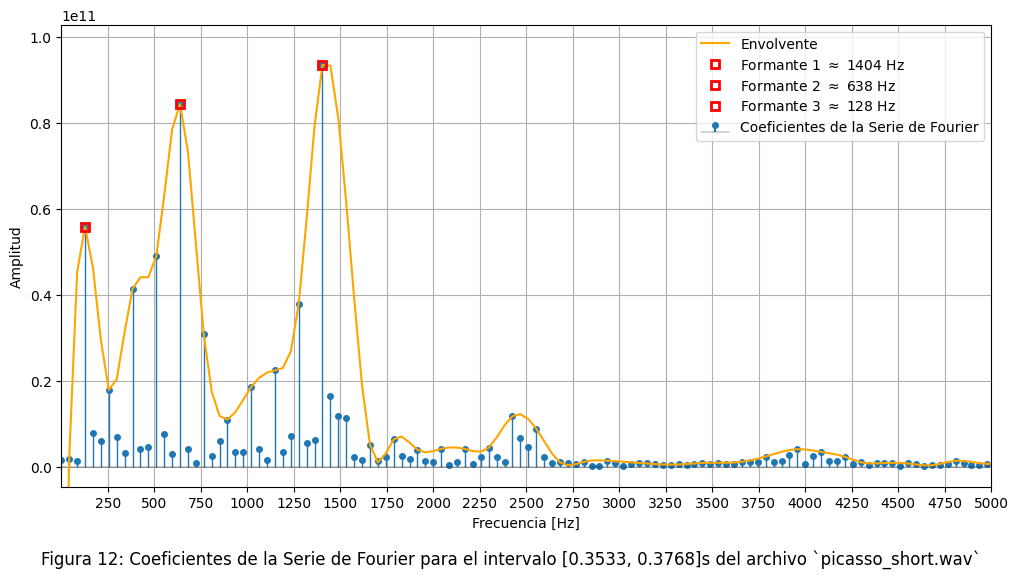

In [19]:
t=0.3533
dt=0.0235
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}]s del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 12, 5000, coef=True, ticks=250)

Para la segunda vocal "i", se identifica en la señal el intervalo `[0.087, 0.094]s` el cual corresponde con el periodo de una señal periodica. Calculando los coeficientes de Fourier para dicho período resulta como se muestra a continuación en la figura 13, en la cual se puede aproximar los primeos 2 formantes a `2857Hz` y `1571Hz`, el tercer formante de la interpolación resulta en `7000Hz`, este último parece ser un error debido a como se traza la curva envolvente mediante la interpolación de los maximos locales de los coeficientes de Fourier, viendolo a "ojo" uno podría decir que el primer formante debería estar cercano a los `200Hz` y el segundo y tercero si en `2857Hz` y `1571Hz`.

2857
1571
7000


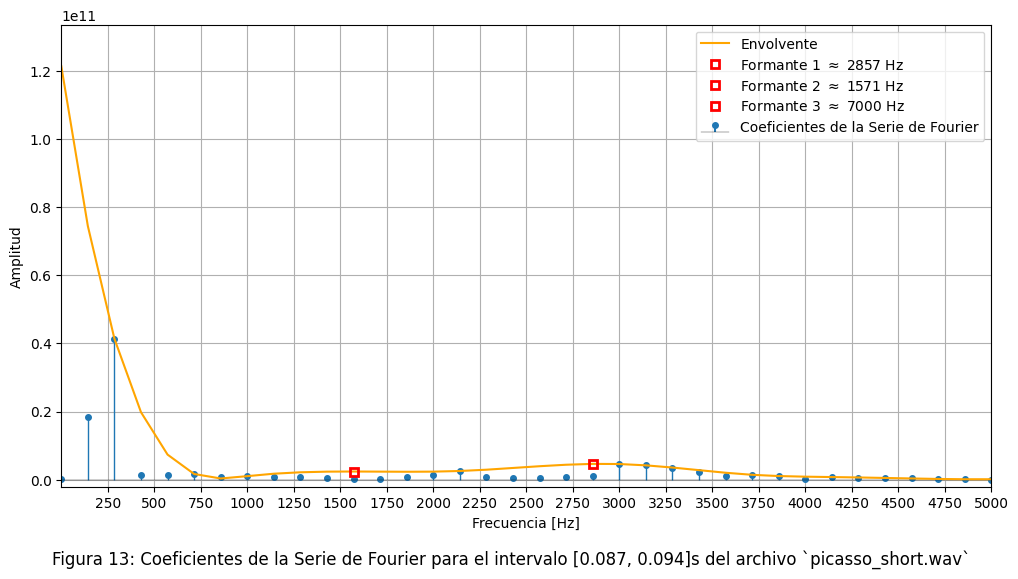

In [20]:
t=0.087
dt=0.007
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}]s del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 13, 5000, coef=True, ticks=250)

Tomando ahora 5 periodos de la señal, por ejemplo el intervalo entre `[0.087, 0.122]s`, los coeficientes de la serie de Fourier resultan como se muestra en la figura 14 a continuación, se ve que los 2 primeros máximos estan en las mismas frecuencias `300Hz` y `180Hz`, pero aparecen otros máximos que para el caso de un solo período no estaban, por ejemplo el tercer máximo en `250Hz`.

Tomando ahora 5 periodos de la señal, por ejemplo el intervalo entre `[0.087, 0.122]s`, los coeficientes de la serie de Fourier resultan como se muestra en la figura 14 a continuación, se ve que al tener más datos para calcular la envolvente mediante interpolación el gráfico es más acorde a lo que se mencionó antes, de que el primer formante deberia estar cercano a los `200Hz`. En este caso los primeros 3 formantes resultan en `229Hz`, `486Hz` y `3200Hz` respectivamente.

229
486
3200


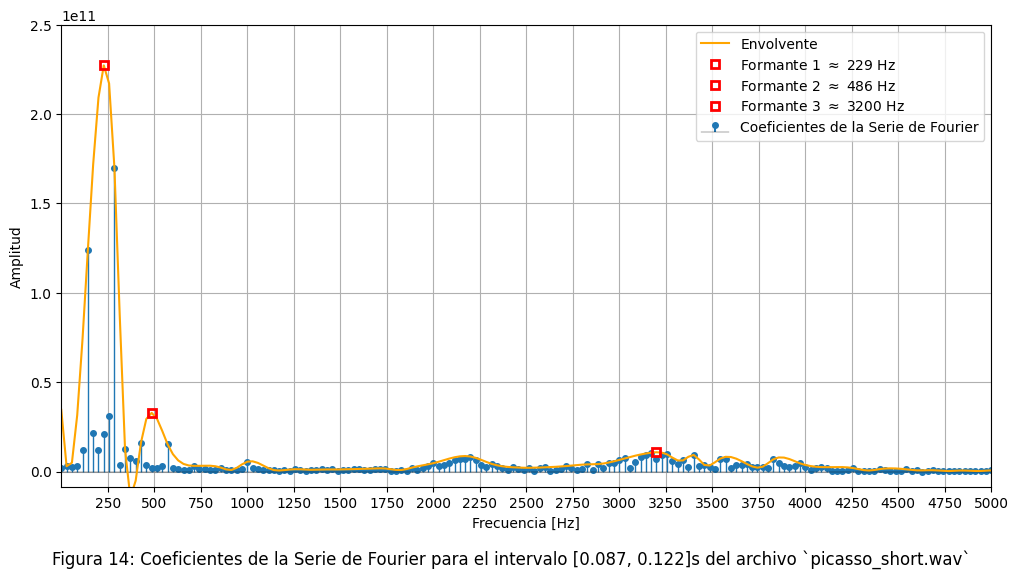

In [21]:
t=0.087
dt=5*0.007
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}]s del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 14, 5000, coef=True, ticks=250)

Finalmente, para  la vocal "o", se identifica el intervalo `[0.634, 0.643]s`, graficando los coeficientes de Fourier, resultan como en la figura 15 a continuación, se ve el primer máximo en aproximadamente `125Hz`, y el segundo y tercer maximo en aproximadamente `200Hz` y `300Hz` respectivamente.

Finalmente, para  la vocal "o", se identifica el intervalo `[0.634, 0.643]s`, graficando los coeficientes de Fourier, resultan como en la figura 15 a continuación, en este caso ocurre similar que en la figura 13, en la cual el tercer formante era muy alto, en este caso el segundo y tercer formante parecen no tener una correlación con el gráfico, si no mas bien parecerian que a "ojo" se encuentran cercanos a los ``1000Hz` y `700Hz` respectivamente. En este caso el primer formante que parece ser correcto el primero que resulta en `1000Hz` aproximadamente.

1000
5000
7444


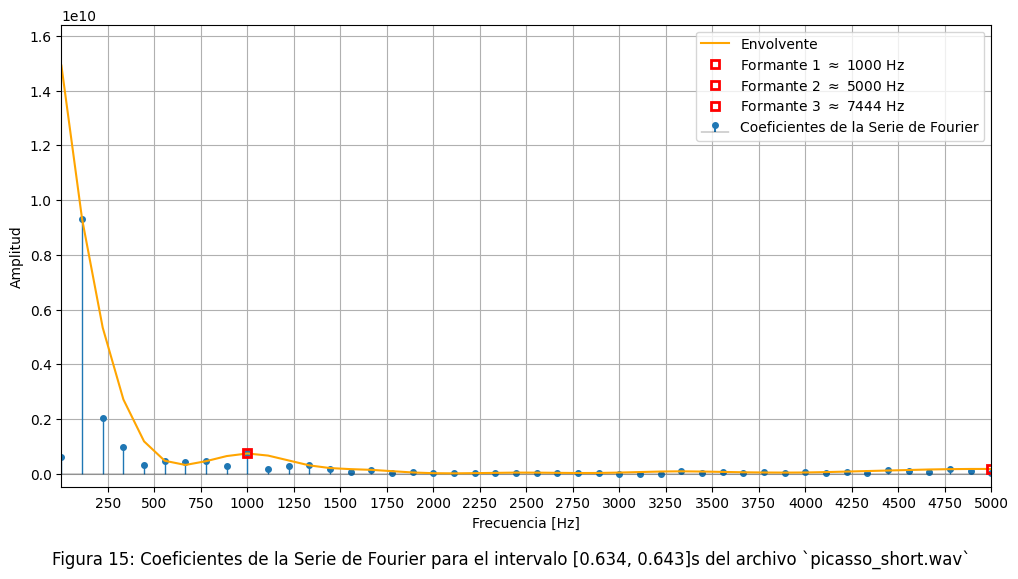

In [22]:
t=0.634
dt=0.009
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}]s del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 15, 5000, coef=True, ticks=250)

Y tomando mas periodos, por ejemplo para aproximadamente 6 periodos, se toma el intervalo `[0.634, 0.588]s`, el grafico de los coeficientes de Fourier resulta como se muestra en la figura 16, en la cual si se observan correctamente los formantes que resultan en `93Hz`, `333Hz` y `574Hz` respectivamente.

93
333
574


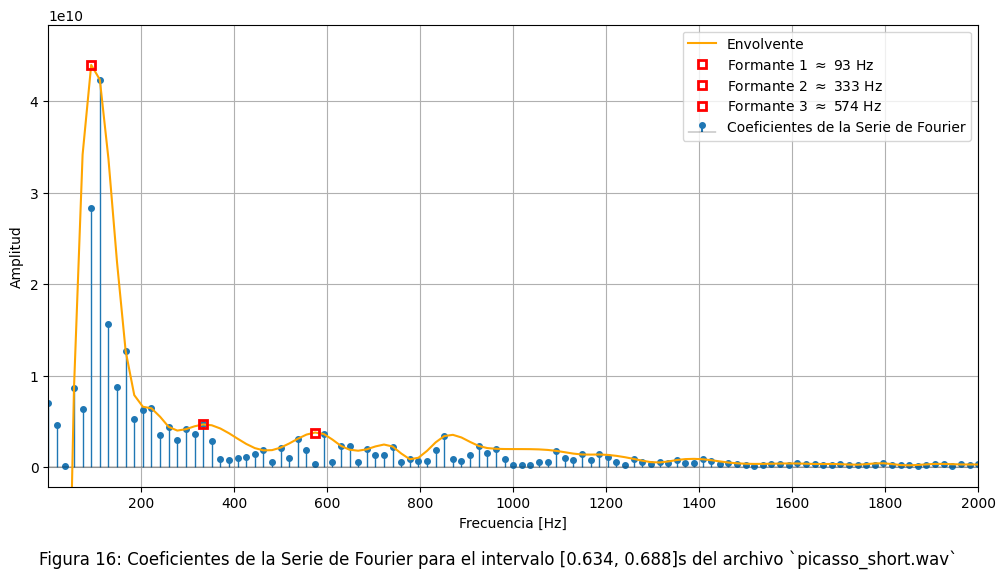

In [23]:
t=0.634
dt=6*0.009
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}]s del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 16, 2000, coef=True, ticks=200)

### Archivo largo

De manera análoga a lo realizado para el archivo corto, se identifican los intervalos de la señal larga en los cuales aparecen sonidos vocálicos. Comenzando por la `[a]` se considera el intervalo que se tomó para la figura 9, pero se toma solo un periodo, `[0.74, 0.748]s`. A continuación se muestra en la figura 17 un gráfico de los coeficientes de Fourier para este intervalo. A ojo se ven los primeros 3 formantes en aproximadamente `125Hz`, `1250Hz` y `2700Hz`, respectivamente. Mediante el calculo de la envolvente por interpolacion cubica, los primeros 2 formantes resultan en `1250Hz` y `2625Hz` respectivamente, y el tercero muy alto debido a un error en como se calcula la envolvente.

1250
2625
19000


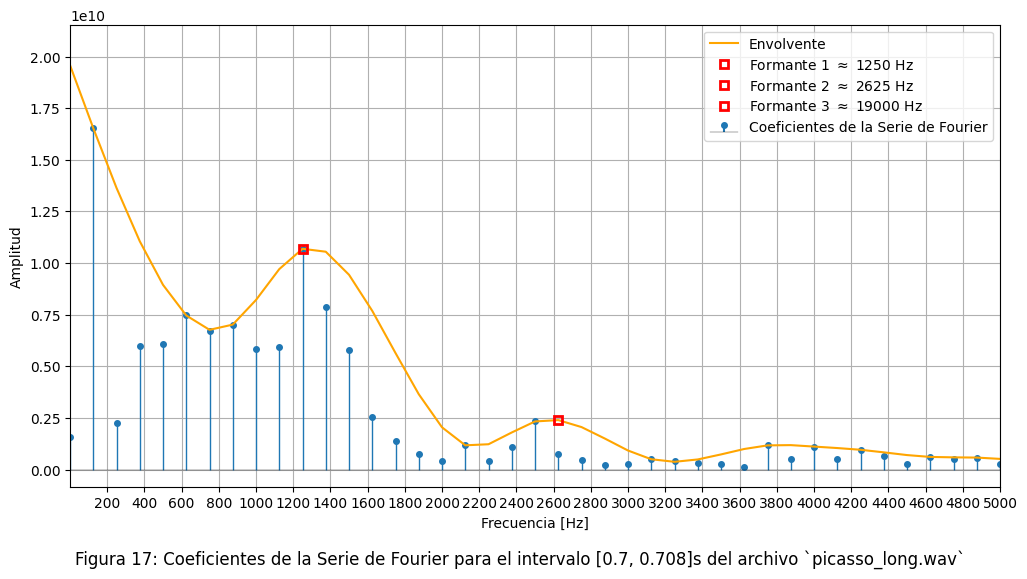

In [24]:
t=0.7
dt=0.008
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}]s del archivo `{long_sample_file_name}`'
graph_fourier(long_sample_data, long_sample_fs, t, dt, title, 17, 5000, coef=True, ticks=200)

Repitiendo, pero para 9 ciclos de la señal, resulta como se ve en la figura 18 a continuación, en la cual se toma el intervalo `[0.708, 0.786]s`. Se pueden ver correctamente los primeros 3 formantes en aproximadamente `90Hz`, `1449Hz` y `643Hz` respectivamente.

90
1449
834


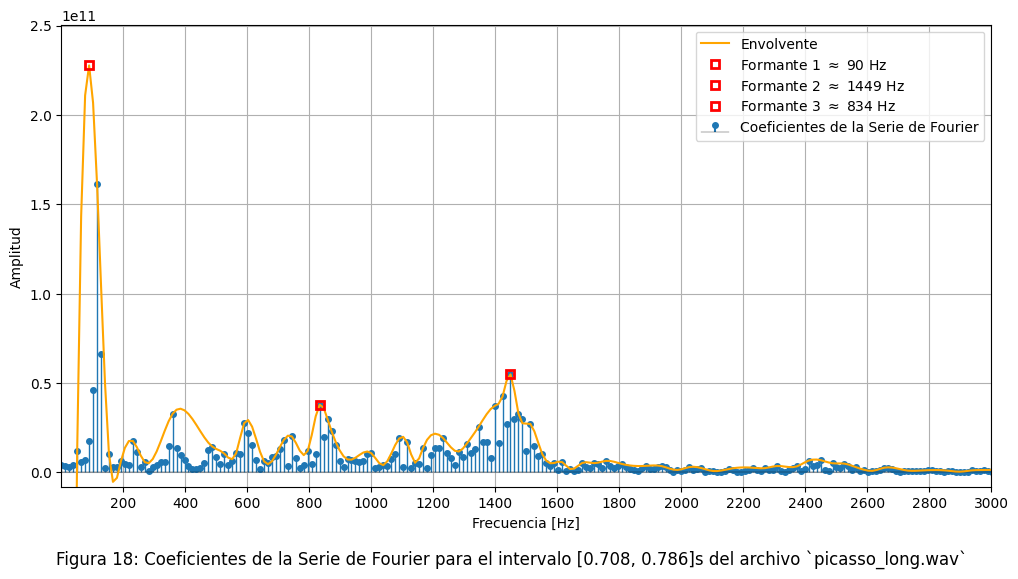

In [25]:
t=0.708
dt=0.078
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {round(t+dt, 3)}]s del archivo `{long_sample_file_name}`'
graph_fourier(long_sample_data, long_sample_fs, t, dt, title, 18, 3000, coef=True, ticks=200)

Siguiendo con el sonido vocálico correspondiente a pronunciar la “i”, se identifica el intervalo en el cual se pronuncia parte de esta vocal en `[0.106, 0.216]s` en este intervalo se ven múltiples ciclos de la señal periódica. Tomando el intervalo `[0.106, 0.114]s` se obtiene solo un periodo de la señal, los coeficientes de Fourier para este intervalo resultan como se muestra en la figura 19 a continuación, en los cuales se ven los principales formantes en aproximadamente `3760Hz`, `3133Hz` y `2256Hz` respectivamente, aunque a "ojo" lo correcto sería que el primer formante esté cercano a los `200Hz`

3760
3133
2256


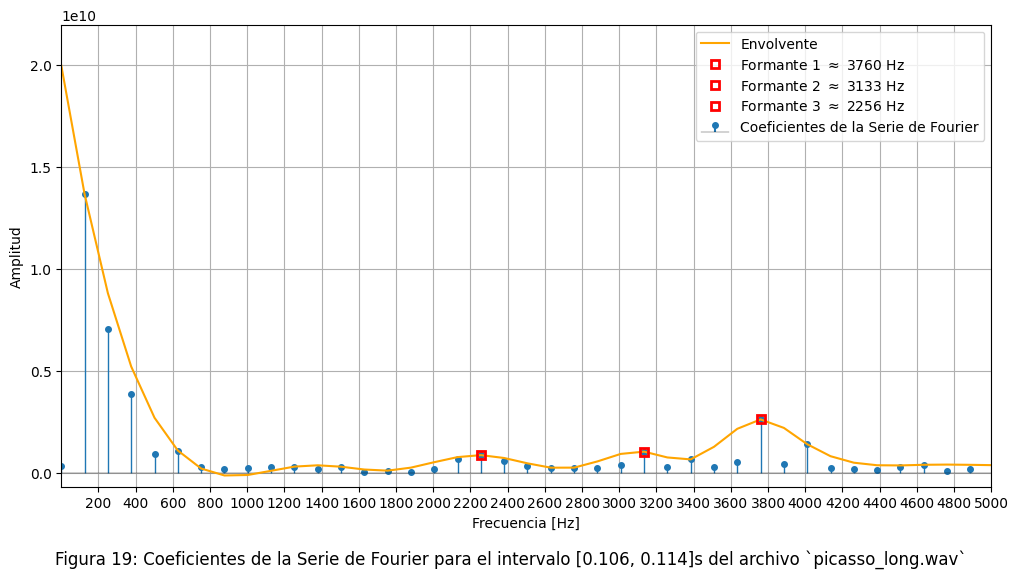

In [26]:
t=0.106
dt=0.008
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {round(t+dt, 3)}]s del archivo `{long_sample_file_name}`'
graph_fourier(long_sample_data, long_sample_fs, t, dt, title, 19, 5000, coef=True, ticks=200)

Tomando múltiples períodos de la señal, resulta como se ve en la figura 20, en la cual se grafican los coeficientes de Fourier para el intervalo `[0.106, 0.151]s` en el cual se encuentran 6 periodos de la señal. De la figura se ven los principales formantes en aproximadamente `133Hz`, `289Hz` y `600Hz`.

133
289
600


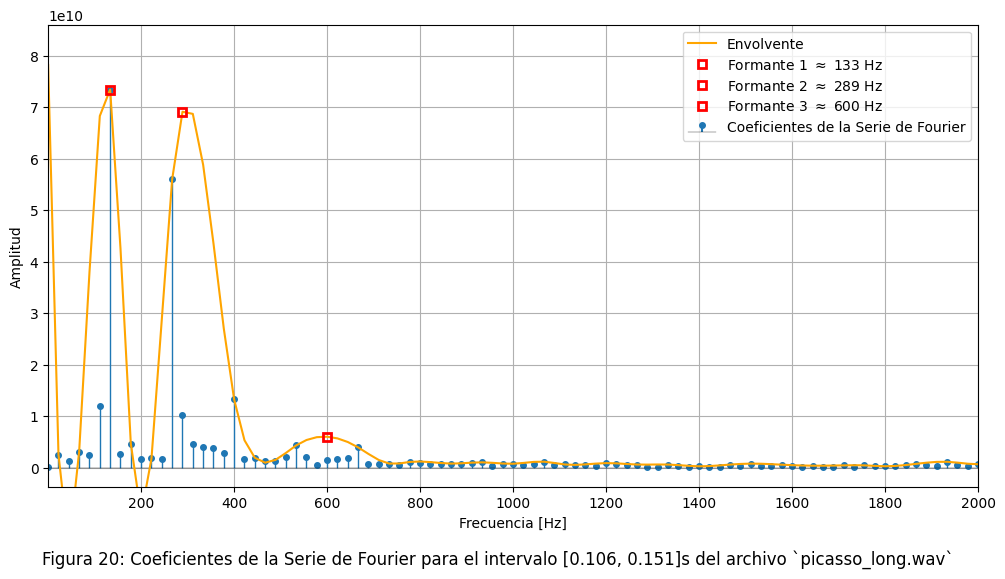

In [27]:
t=0.106
dt=0.045
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {round(t+dt, 3)}]s del archivo `{long_sample_file_name}`'
graph_fourier(long_sample_data, long_sample_fs, t, dt, title, 20, 2000, coef=True, ticks=200)

Finalmente para el sonido vocálico `[o]`, se identifica en la señal el intervalo `[1.353, 1405]s` en el cual se encuentra aproximadamente 6 períodos de la señal, tomando un único periodo por ejemplo en el intervalo `[1.368, 1.379]s` y calculando y graficando los coeficientes de Fourier, resulta como se ve en la figura 21 a continuación. En gráfico se muestran los principales formantes que no son correctos, ya que a "ojo" deberian ser cercanos a `120Hz`, `600Hz` y `800Hz` respectivamente.

2818
2000
3455


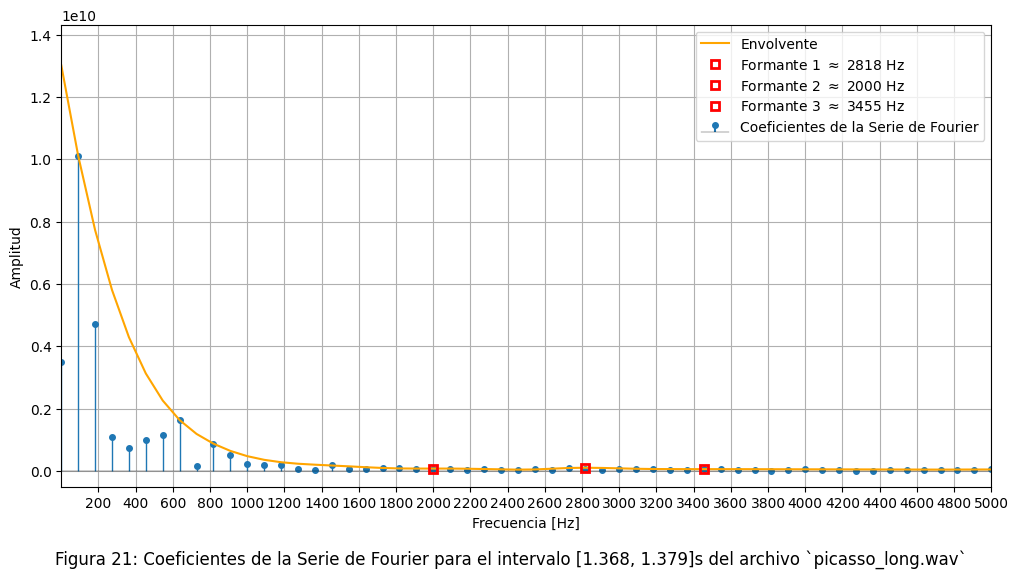

In [28]:
t=1.368
dt=0.011
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {round(t+dt, 3)}]s del archivo `{long_sample_file_name}`'
graph_fourier(long_sample_data, long_sample_fs, t, dt, title, 21, 5000, coef=True, ticks=200)

Por último, tomando los 6 periodos del interalo mencionado, la serie de Fourier resulta como en la figura 22 a continuación. Los primeros 3 formantes resultan en `135Hz`, `615Hz` y `462Hz`, respectivamente, y parecen tener una mejor correlacion con lo visto a "ojo", aunque no es del todo correcta ya que debería haber un segundo formante cercano a los `250Hz`

135
615
462


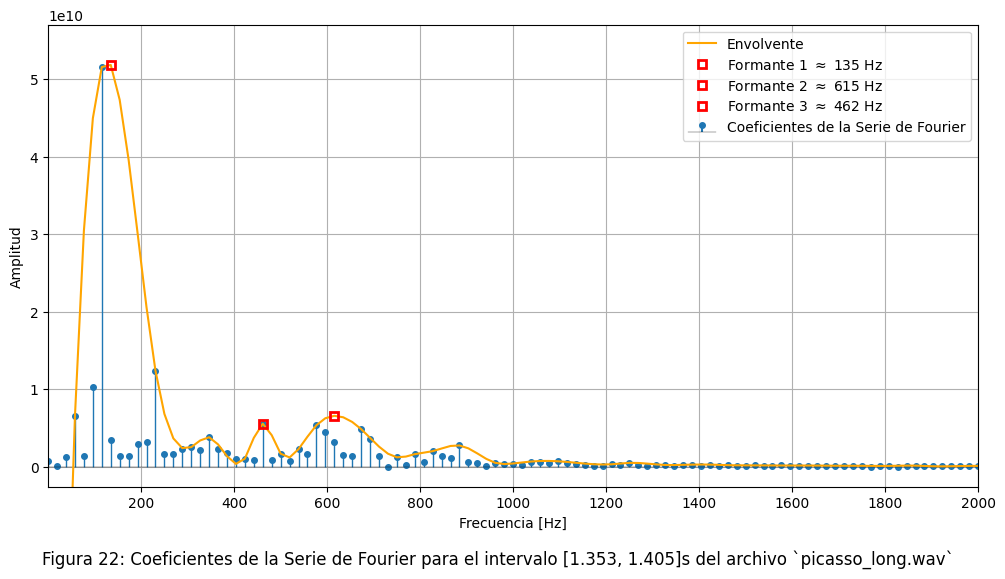

In [29]:
t=1.353
dt=0.052
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {round(t+dt, 3)}]s del archivo `{long_sample_file_name}`'
graph_fourier(long_sample_data, long_sample_fs, t, dt, title, 22, 2000, coef=True, ticks=200)

### Resultados

En la tabla a continuacion se muestran los resultados obtenidos del análisis previo

| Vocal | Formante | Archivo corto (un periodo) | Archivo corto (más de un periodo) | Archivo largo (un periodo) | Archivo largo (más de un periodo) |
|:-----:|:--------:|:--------------------------:|:---------------------------------:|:---------------------------:|:----------------------------------:|
|   a   |    1     |           750   Hz           |              1404 Hz               |           1250  Hz          |                90   Hz              |
|   a    |    2     |          2500   Hz           |               638    Hz            |           2625   Hz          |              1449   Hz              |
|   a    |    3     |          3875   Hz           |               128    Hz            |          19000   Hz          |               834   Hz              |
|   i   |    1     |          2857     Hz         |               229    Hz            |           3760   Hz          |               133   Hz              |
|    i   |    2     |          1571    Hz          |               486   Hz             |           3133    Hz         |               289   Hz              |
|   i    |    3     |          7000    Hz          |              3200    Hz            |           2256   Hz          |               600     Hz            |
|   o   |    1     |          1000     Hz         |                93      Hz          |           2818    Hz         |               135 Hz                |
|   o    |    2     |          5000    Hz          |               333  Hz              |           2000    Hz         |               615  Hz               |
|    o   |    3     |          7444     Hz         |               574   Hz             |           3455     Hz        |               462  Hz               |


## Espectograma

Para realizar el grafico de espectogramas se utiliza el metodo [spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html#spectrogram) del modulo [scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html#signal-processing-scipy-signal).

In [30]:
from scipy.signal import spectrogram

 Se define la funcion `graph_spectogram` para mantener el codigo modularizado, análogo a lo realizado en la instancia anterior con la funcion `graph_data`.

In [31]:
def graph_spectrogram(data, sample_rate, t, dt, title, fig_num, f_min, f_max, factor):
  i = int(t*sample_rate)
  di = int((t+dt)*sample_rate)
  interval_data = data[i:di]

  # f, time, Sxx = spectrogram(interval_data, fs=sample_rate)
  f, time, Sxx = spectrogram(interval_data, fs=sample_rate, nperseg=1024, noverlap=512)
  graph_data(time, f, title, fig_num, t=0, dt=0, plot_type="spectogram", tick=0, mesh_data=Sxx*factor, y_max=f_max)

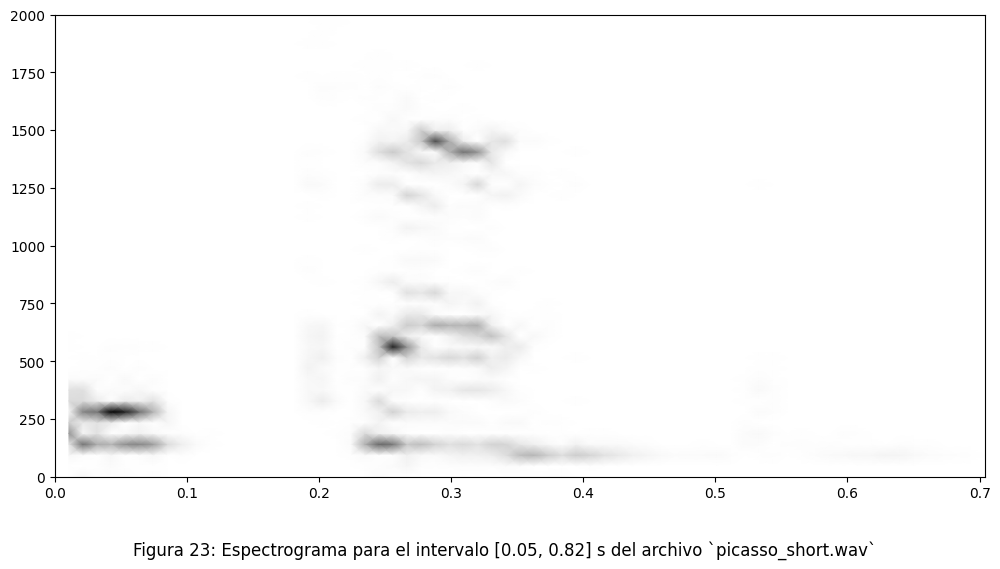

In [32]:
t=0.05
dt=0.77

title = f'Espectrograma para el intervalo [{t:.2f}, {t+dt:.2f}] s del archivo `{short_sample_file_name}`'
graph_spectrogram(short_sample_data, short_sample_fs, t, dt, title, 23, 20, 2000, 0.5)

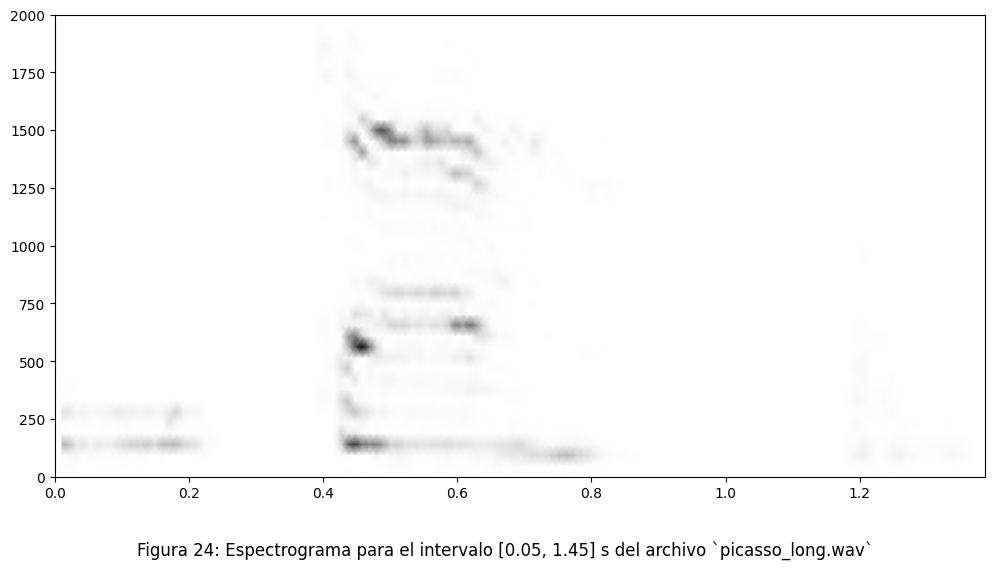

In [33]:
dt=0.0
dt=1.4

title = f'Espectrograma para el intervalo [{t:.2f}, {t+dt:.2f}] s del archivo `{long_sample_file_name}`'
graph_spectrogram(long_sample_data, long_sample_fs, t, dt, title, 24, 20, 2000, 0.5)